# Calibrating X6Y3 — the full process (co-simulation)

The **complete calibration process** of the flux-tunable-qubit walkthrough, minus everything flux
(X6Y3 is fixed-frequency), run end-to-end against the Verilated `PulseTableSoc`. Spec
[software/14](../specs/software/14-full-calibration-x6y3.md) is the audit that defines the scope;
this notebook is its stage-by-stage record.

The arc is the walkthrough's own, in its order:

| Stage | What it establishes |
|---|---|
| **1 — readout** | where the resonator is and how hard to drive it, then a discriminator you can trust: `Punchout` → `ReadoutCalibration` → `Separation` → `Fidelity` → the `Window` knobs → the confusion matrix |
| **2 — frequency & coherence** | the qubit's carrier and how long it stays coherent: `Frequency` (Ramsey V-fit) → `T1` → `T2` → the `RPEFrequency` polish |
| **3 — one-qubit gates** | a working X90, its axis, the EF subspace above it, and the DRAG envelope: `Amplitude` → `Phase` → the `RPEAmplitude`/`RPEPhase` polish → `T1`/`T2` → the 3-level classifier + `EFFrequency`/`EFAmplitude`/`EFPhase` → `optimize_fast_drag` |
| **4 — the two-qubit gate** | the CZ, seeded then refined: `calc_cz_frequency` → `JAZZ` → `CZAmpFreqSweep` (the 2D landscape) → `CZSweep` → `CZFrequency` → `RelativePhase` → `CZAmplitude` → `LocalPhases` → the `CZRPE` polish → `SpectatorPhase` |
| **5 — validation** | that the calibrated gate survives amplification: the conditionality R at n = 1 vs n = 3 |

Every stage is the same round trip — `Config.from_qcal` → run → fit → `apply()` → `save_qcal` —
through one qcal tree ([`calibration_x6y3_full_cosim.yaml`](calibration_x6y3_full_cosim.yaml)), so
the artefact at the end is the artefact a real session would hand on.

**What is planted.** There is no qubit here: each core drives a planted model
(`TwoLevelModel` → `ThreeLevelModel` → the drive-form `TwoQubitModel`) whose ground truth the
notebook knows, and every stage is scored against it. Knobs are sized for co-sim wall time, not for
precision — the point is that each code path runs and converges toward known truth. The committed
`--cosim` pytest gates pin the same paths down tightly.

This supersedes `calibration_x6y3_full_cosim.ipynb`, which covered the readout / 1Q / EF /
two-qubit spine but none of the F2–F5 stages (punchout, the readout-window knobs, coherence, the
3-level confusion matrix, DRAG, the 2D CZ landscape, the RPE polish).

In [1]:
import math
import shutil
import time
from pathlib import Path

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

import riscq
from riscq import run as rq
from riscq.cal import (Amplitude, CZAmpFreqSweep, CZAmplitude, CZFrequency, CZRPE, CZSweep,
                       ClassifierN, Config, EFAmplitude, EFFrequency, EFPhase, Fidelity, Frequency,
                       JAZZ, LocalPhases, Phase, Punchout, RPEAmplitude, RPEFrequency, RPEPhase,
                       ReadoutCalibration, ReadoutFidelity, RelativePhase, Separation,
                       SpectatorPhase, T1, T2, Window, calc_cz_frequency, optimize_fast_drag,
                       pair_key, rcorr)
from riscq.cal.analysis.rpe import CZ_TARGETS
from riscq.cal.base import GATE_ENV, gate_pulse, gate_sigma
from riscq.cal.cz import _cz_dur_batches, _cz_pulse
from riscq.cal.experiment import Experiment
from riscq.cal.gates import resolve
from riscq.cal.measure import Measure
from riscq.map import SocMap, SocParams
from riscq.pulses import Pulse, units
from riscq.sim import server

MHz, GHz, us = 1e6, 1e9, 1e-6
T0 = time.time()

def mark(label):
    print(f'[{time.time() - T0:7.1f}s] {label}')

## Bring up the co-sim and the config of record

`server.start` Verilates the 3-core `sim-2q1c` build (2 qubits + the spectator neighbour) and
returns a driver with the same four methods the ZCU216 board server exposes — every cell below is
byte-identical to what it would be against hardware. The tree of record is copied to a **working
file** that each cell reloads and each applied proposal is saved back into.

In [2]:
SW = Path(riscq.__file__).resolve().parents[1]              # .../software
SRC = SW.parent / 'examples' / 'calibration_x6y3_full_cosim.yaml'
WORK = SW / 'build' / 'calibration_process_config.yaml'     # the working copy
WORK.parent.mkdir(exist_ok=True)
shutil.copy(SRC, WORK)

drv = server.start(SW / 'configs' / 'sim-2q1c.json', SW / 'build' / 'sim-2q1c')
m = SocMap(SocParams.from_json(drv.sim.get_params()))
QUBITS = [0, 1]                  # the calibrated pair (one per core)
PAIR = (0, 1)
SPECT = 2                        # the ring neighbour — SpectatorPhase's bystander
ALL = [0, 1, SPECT]              # readout is calibrated on ALL cores (the spectator's fringe
                                 # reads through its OWN discriminator)

cfg = Config.from_qcal(WORK)
cfg.check_hardware(m.params)     # the tree's hardware section must describe THIS build (spec 13 Q0)
print('cosim up; qubits =', QUBITS, ' spectator =', SPECT, ' herald =', cfg['readout/herald'])

def step(cal):
    '''run -> print -> apply if ok -> persist to the working tree (qcal's auto write-back).'''
    t = time.time()
    r = cal.run(drv)
    print(f'{r.label}: ok={r.ok}  [{time.time() - t:.0f}s]  proposal={r.proposal}')
    if r.ok:
        r.apply()
        r.cfg.save_qcal(WORK)
    else:
        print('  fit failed — config left unchanged (fail-loud, spec 13 §2)')
    return r

cosim up; qubits = [0, 1]  spectator = 2  herald = True


## Plant the ground truth and mis-set the starting tree

Each core gets a projective `TwoLevelModel` at its own carrier with a planted Rabi rate; the
readout tones sum on the shared ADC. Then the tree's carriers are deliberately pushed **±40 codes**
off truth (both signs, so a sign slip in any correction shows up) — stage 2 has to pull them back.

In [3]:
F_GE = {0: 50e6, 1: 150e6, 2: 100e6}       # codes 2048 / 6144 / 4096
F_EF = {0: 450e6, 1: 650e6}                 # codes 18432 / 26624
RO_CODE = {0: 2048, 1: 1024, 2: 3072}       # the readout multiplex slots

def x90_sigma(q, amp):
    '''The drive integral of one full X90 at `amp` — the sigma the models integrate.'''
    p = Pulse(GATE_ENV, freq_hz=F_GE[q], amp=amp)
    return gate_sigma(m, p, F_GE[q], units._amp_code(amp))

SIG_MAX = {q: x90_sigma(q, 0.97) for q in ALL}
RABI = {0: 3 * math.pi / SIG_MAX[0], 1: 5 * math.pi / SIG_MAX[1],   # odd multiples of pi full-scale
        2: math.pi / SIG_MAX[2]}                                    # spectator: a plain pi prep
TRUE_AMP = {q: 0.97 * (math.pi / 2) / (RABI[q] * SIG_MAX[q]) for q in QUBITS}

# readout budget: relax (2400) >> t1 (600) >> SEP. The cluster separation is T1-DECAY-bounded, so
# t1 keeps the 1Q twin's 600 while the relax head runs 0.75x.
def twolevel_models():
    return [dict(kind='twolevel', core=q, rabi_rad_per_amp=RABI[q], readout_code=RO_CODE[q],
                 readout_amp=10000.0, readout_phase=0.0, f_ge=F_GE[q], t1=600, t2=3000,
                 noise_scale=200.0, noise_seed=11 + q, collapse=True) for q in ALL]

drv.sim.set_model({'kind': 'multi', 'models': twolevel_models()})

D_CODE = {0: +40, 1: -40}
cfg = Config.from_qcal(WORK)
for q in QUBITS:
    off = units._freq_code(F_GE[q], m.params) + D_CODE[q]
    cfg[f'qubit/{q}/freq'] = float(units.code_to_freq(off, m.params))
cfg.save_qcal(WORK)
for q in QUBITS:
    print(f"q{q}: start freq err {abs(cfg[f'qubit/{q}/freq'] - F_GE[q]):.4g} Hz   "
          f"X90 amp {cfg[f'qubit/{q}/x90/amp']} (true ~{TRUE_AMP[q]:.4f})")

q0: start freq err 9.766e+05 Hz   X90 amp 0.5 (true ~0.1617)
q1: start freq err 9.766e+05 Hz   X90 amp 0.5 (true ~0.0970)


# Stage 1 — readout

Nothing else can be measured until a shot can be classified, so the process starts here. The
walkthrough's order: find the resonator and the drive power that resolves it (**punchout**), train
the discriminator, then tune each readout knob against a metric that the discriminator itself
defines.

## Punchout — the frequency × drive-power map

The resonator pulls with drive power: weak tones see the dressed (qubit-coupled) frequency, strong
tones saturate it back to the bare cavity. `Punchout` is the host amp loop over the same
wideband-VNA rerun the bring-up tool uses, and the map is what tells you which amp to hand
`Separation` and `Fidelity` below.

Here the planted readout is a flat tone with no power dependence, so the map is deliberately
featureless — this cell exercises the sweep, not a pull. On a real chip the ridge moves.

[    2.6s] S1 punchout


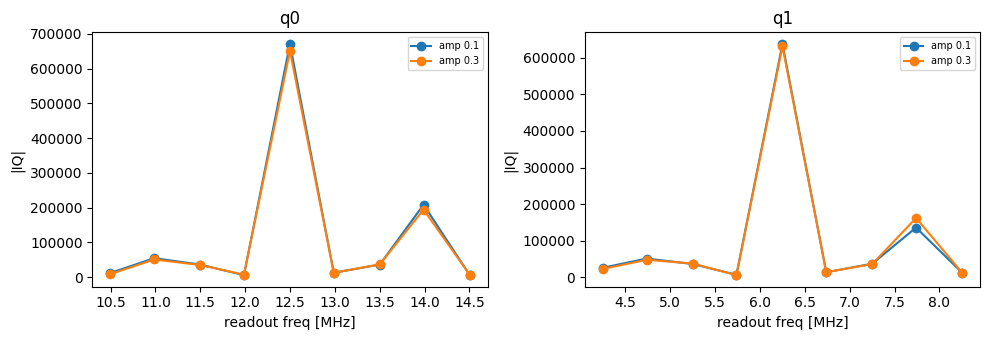

punchout is a bring-up MAP — it proposes nothing: {}


In [4]:
mark('S1 punchout')
cfg = Config.from_qcal(WORK)
po = Punchout(cfg, QUBITS, amps=(0.1, 0.3), span=2 * MHz, points=9, shots=8).run(drv)

fig, axes = plt.subplots(1, len(QUBITS), figsize=(10, 3.5))
for q, ax in zip(QUBITS, np.atleast_1d(axes)):
    d = po.data[q]
    for i, a in enumerate(d['amps']):
        ax.plot(d['x'] / MHz, d['mag'][i], 'o-', label=f'amp {a:g}')
    ax.set_title(f'q{q}'); ax.set_xlabel('readout freq [MHz]'); ax.set_ylabel('|IQ|')
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()
print('punchout is a bring-up MAP — it proposes nothing:', po.proposal)

## The discriminator, then the readout knobs

`ReadoutCalibration` captures |0⟩/|1⟩ RAW clouds and fixes each qubit's `demod/phase` + `res_sign`
— the on-chip discriminator every counts-mode step below reads through. Then, with that
discriminator held fixed: `Separation` re-pins `readout/{q}/freq` by cluster-SNR argmax, and
`Fidelity` sweeps the readout amp.

ReadoutCalibration [0, 1, 2]: ok=True  [40s]  proposal={'readout/0/demod/phase': 1.5771919589783037, 'readout/0/res_sign': 1, 'readout/1/demod/phase': 0.7871225374472802, 'readout/1/res_sign': 1, 'readout/2/demod/phase': 2.359154815320273, 'readout/2/res_sign': 1}


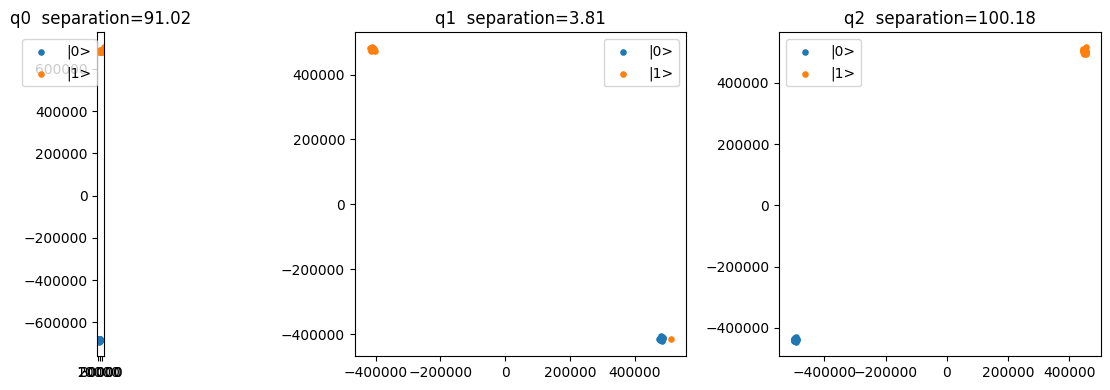

In [5]:
cfg = Config.from_qcal(WORK)
rc = step(ReadoutCalibration(cfg, ALL, shots=32, gate='X90'))

fig, axes = plt.subplots(1, len(ALL), figsize=(12, 4))
for q, ax in zip(ALL, axes):
    d = rc.data[q]
    ax.scatter(d['iq0'][:, 0], d['iq0'][:, 1], s=14, label='|0>')
    ax.scatter(d['iq1'][:, 0], d['iq1'][:, 1], s=14, label='|1>')
    ax.set_title(f"q{q}  separation={d['separation']:.2f}")
    ax.set_aspect('equal'); ax.legend()
plt.tight_layout(); plt.show()
assert all(rc.data[q]['separation'] > 1.0 for q in ALL), 'clusters must separate'

Separation [0, 1, 2]: ok=False  [128s]  proposal={'readout/0/freq': 13964843.75, 'readout/1/freq': 7714843.75, 'readout/2/freq': 20214843.75}
  fit failed — config left unchanged (fail-loud, spec 13 §2)


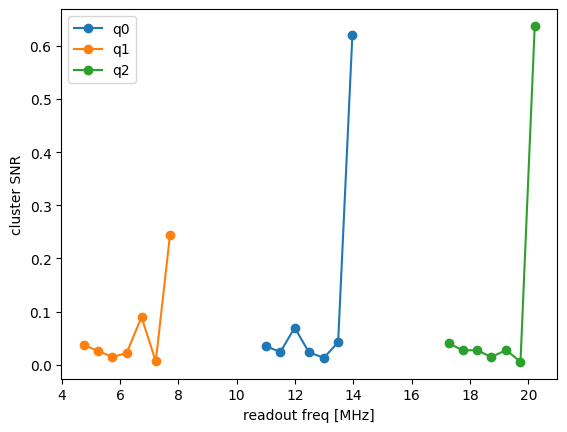

Fidelity [0, 1, 2]: ok=True  [103s]  proposal={'readout/0/amp': 0.5, 'readout/1/amp': 0.4974869320466425, 'readout/2/amp': 0.4974869320466425}


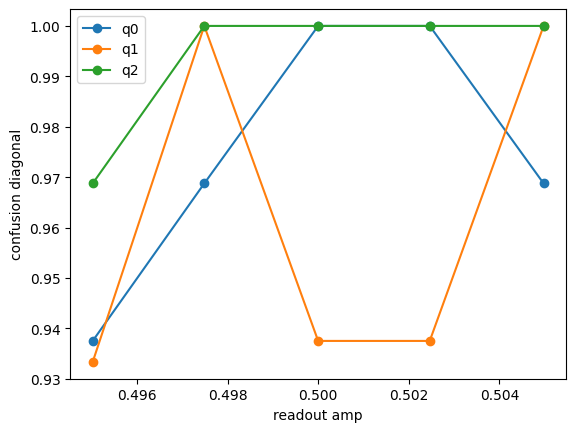

In [6]:
cfg = Config.from_qcal(WORK)
sep = step(Separation(cfg, ALL, span=1.5 * MHz, points=7, shots=16, gate='X90'))

for q in ALL:
    plt.plot(sep.data[q]['x'] / MHz, sep.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('readout freq [MHz]'); plt.ylabel('cluster SNR'); plt.legend(); plt.show()

cfg = Config.from_qcal(WORK)
fid = step(Fidelity(cfg, ALL, amp_span=0.005, points=5, shots=16, gate='X90'))
for q in ALL:
    plt.plot(fid.data[q]['x'], fid.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('readout amp'); plt.ylabel('confusion diagonal'); plt.legend(); plt.show()

## The window knobs — how long to listen, and when to start

Three more knobs the walkthrough tunes and the earlier notebooks did not (spec 14 F2). None of them
is an on-core sweep — the two durations are readout table-slot fields, the delay is a per-run kernel
param — so `Window` reruns the measurement once per value and takes the argmax of the confusion
diagonal, the same metric `Fidelity` scores:

- `demod/dur` — how long the integrator is open;
- `readout/dur` — how long the drive tone plays;
- `demod/delay` — how long after the drive starts the integrator opens (the cable + cavity ring-up).

[  353.6s] S1 window knobs


Window [0, 1] demod/dur: ok=True  [61s]  proposal={'readout/0/demod/dur': 4.0000000000000003e-07, 'readout/1/demod/dur': 3.0000000000000004e-07}


Window [0, 1] dur: ok=True  [61s]  proposal={'readout/0/dur': 4.0000000000000003e-07, 'readout/1/dur': 4.0000000000000003e-07}


Window [0, 1] demod/delay: ok=True  [61s]  proposal={'readout/0/demod/delay': 8e-08, 'readout/1/demod/delay': 4e-08}


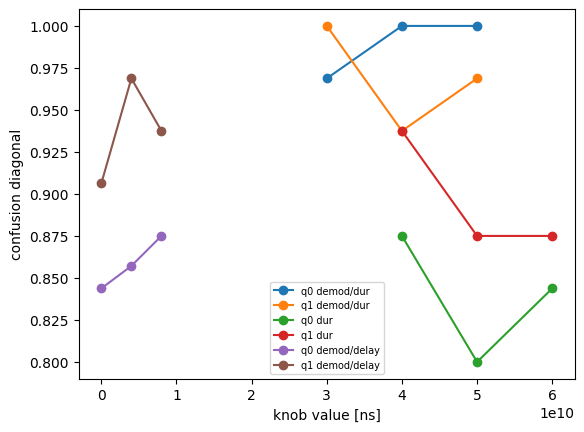

In [7]:
mark('S1 window knobs')
for knob, durs in (('demod/dur', (3.0e-07, 4.0e-07, 5.0e-07)),
                   ('dur', (4.0e-07, 5.0e-07, 6.0e-07)),          # the readout DRIVE length
                   ('demod/delay', (0.0, 4.0e-08, 8.0e-08))):
    cfg = Config.from_qcal(WORK)
    w = step(Window(cfg, QUBITS, durs=durs, shots=16, gate='X90', knob=knob))
    for q in QUBITS:
        d = w.data[q]
        plt.plot(np.array(d['x']) * 1e9, d['y'], 'o-', label=f'q{q} {knob}')
plt.xlabel('knob value [ns]'); plt.ylabel('confusion diagonal'); plt.legend(fontsize=7); plt.show()

## The confusion matrix

`ReadoutFidelity` prepares each level and records how often it is classified as each level. The
2-level matrix is the assignment fidelity; the **3-level** one is what stage 3's leakage numbers
need, and it needs the 3-level classifier trained there — so it is measured again in stage 3, and
`rcorr` inverts it to turn measured populations into true ones.

In [8]:
cfg = Config.from_qcal(WORK)
rof = step(ReadoutFidelity(cfg, ALL, shots=32, gate='X90'))

for q in ALL:
    print(f'q{q} confusion (row = prepared, col = classified):')
    print(np.round(rof.data[q]['confusion'], 3), f"  fidelity={rof.data[q]['fidelity']:.3f}")

ReadoutFidelity [0, 1, 2]: ok=True  [43s]  proposal={'readout/0/fidelity': 0.9375, 'readout/1/fidelity': 0.953125, 'readout/2/fidelity': 0.967741935483871}
q0 confusion (row = prepared, col = classified):
[[1.    0.   ]
 [0.125 0.875]]   fidelity=0.938
q1 confusion (row = prepared, col = classified):
[[1.    0.   ]
 [0.094 0.906]]   fidelity=0.953
q2 confusion (row = prepared, col = classified):
[[1.    0.   ]
 [0.065 0.935]]   fidelity=0.968


# Stage 2 — the qubit frequency

With shots classifiable, find the carrier. `Frequency` runs Ramsey fringes at a ladder of applied
detunings and fits qcal's `a·|x − b| + c` V — the vertex is the applied detuning that cancels the
tree's error, so the correction is signed and does not need the fringe frequency's sign (which a
magnitude fit cannot give). A Ramsey's fringe *frequency* does not depend on the X90 being a good
X90 (only its contrast does), which is why the carrier can be pinned before the gate is.

The walkthrough measures **coherence** here too. This notebook runs `T1`/`T2` at the end of stage 3
instead, because both need a π pulse that works and the gate amplitude is still uncalibrated at
this point — the one place the order departs from the walkthrough's, and it departs the way a real
bring-up does.

[  580.1s] S2 frequency


Frequency [0, 1]: ok=True  [369s]  proposal={'qubit/0/freq': 50048088.18885179, 'qubit/1/freq': 150140166.58433187}


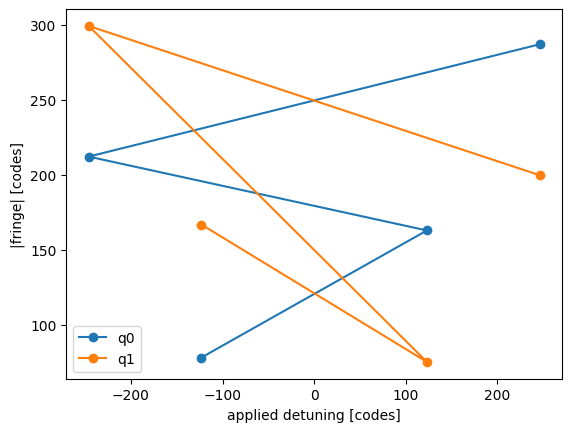

q0: freq err 4.809e+04 Hz (planted 9.766e+05)
q1: freq err 1.402e+05 Hz (planted 9.766e+05)


In [9]:
RELAX_1Q = 1.6e-05               # counts-mode grid (in-memory; the tree keeps the RAW budget)

def cfg1q():
    c = Config.from_qcal(WORK)
    c['reset/relax'] = RELAX_1Q
    return c

mark('S2 frequency')
cfg = cfg1q()
fr = step(Frequency(cfg, QUBITS, detune=3 * MHz, n_detune=4, t0=40e-9, dt=40e-9,
                    points=11, shots=20))

for q in QUBITS:
    d = fr.data[q]
    plt.plot(d['applied'], d['obs'], 'o-', label=f'q{q}')
plt.xlabel('applied detuning [codes]'); plt.ylabel('|fringe| [codes]'); plt.legend(); plt.show()
for q in QUBITS:
    print(f"q{q}: freq err {abs(cfg[f'qubit/{q}/freq'] - F_GE[q]):.4g} Hz "
          f"(planted {abs(units.code_to_freq(D_CODE[q], m.params)):.4g})")

## The RPE polish

`Frequency` is a fit to a fringe and its precision is bounded by the shot noise on that fringe.
**Robust phase estimation** does better: it repeats the idle `d` times so a residual carrier error
writes `d` times the phase, and walks an exponential ladder of `d`, resolving each rung's `2π/d`
ambiguity with the previous rung's estimate. Precision then improves like `1/d` rather than
`1/sqrt(shots)` (spec 14 F5).

RPE is a **polish** step — it refines a carrier that is already close and cannot acquire one from
scratch (a carrier far enough off detunes the drive *during* the pulse, and the X90 stops being an
X90). So the cell below deliberately puts a known, modest error back on the tree for RPE to find,
and sizes the idle so the shallowest rung sees about half a radian.

[  948.9s] S2 RPE frequency


RPEFrequency [0, 1]: ok=True  [662s]  proposal={'qubit/0/freq': 50005824.48477124, 'qubit/1/freq': 150021701.42332652}
q0: contrast=[1.06, 0.97, 0.94, 0.99]  last good depth=8  freq err 5.859e+05 -> 5824 Hz
q1: contrast=[1.07, 0.97, 0.85, 0.82]  last good depth=8  freq err 5.859e+05 -> 2.17e+04 Hz


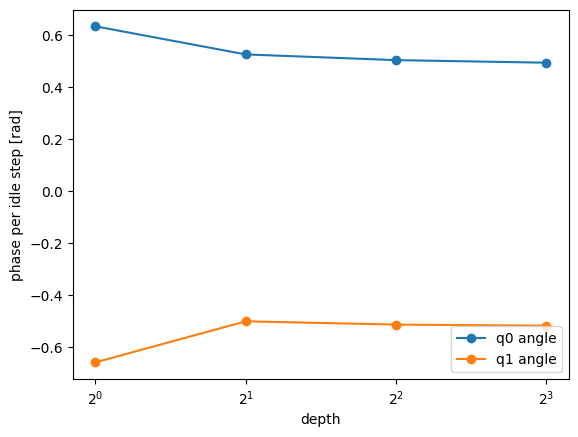

In [10]:
mark('S2 RPE frequency')
RPE_CODE = 24                                     # the residual we hand the polish step
cfg = cfg1q()
for q in QUBITS:
    off = units._freq_code(F_GE[q], m.params) + (RPE_CODE if q == 0 else -RPE_CODE)
    cfg[f'qubit/{q}/freq'] = float(units.code_to_freq(off, m.params))
delta = abs(units.code_to_freq(RPE_CODE, m.params))
t_idle = round(0.5 / (2 * np.pi * delta), 10)     # ~0.5 rad at depth 1
before = {q: abs(cfg[f'qubit/{q}/freq'] - F_GE[q]) for q in QUBITS}

cal = RPEFrequency(cfg, QUBITS, t_idle=t_idle, depths=(1, 2, 4, 8), shots=96)
rpe = step(cal)                                   # step() returns the Result; the ladder is on `cal`

for q in QUBITS:
    a = cal.angles[q]
    plt.plot(a.depths, a.estimates['Z'], 'o-', label=f'q{q} angle')
    print(f"q{q}: contrast={np.round(a.contrast, 2).tolist()}  last good depth={a.last_good_depth}  "
          f"freq err {before[q]:.4g} -> {abs(cfg[f'qubit/{q}/freq'] - F_GE[q]):.4g} Hz")
plt.xscale('log', base=2); plt.xlabel('depth'); plt.ylabel('phase per idle step [rad]')
plt.legend(); plt.show()

# Stage 3 — one-qubit gates

## The X90 amplitude and axis

`Amplitude` first: the coarse Rabi cosine over the full amplitude range pins the scale, then a
narrow relative pass with 4 X90s amplifies what is left. `Phase` then fixes the axis — qcal's two
Rz-decorated sequences over the same sweep, whose populations cross at the calibrated virtual-Z
pair.

[ 1610.7s] S3 amplitude + phase


Amplitude [0, 1] X90 n_gates=1: ok=True  [206s]  proposal={'qubit/0/x90/amp': 0.15732388553332968, 'qubit/0/rabi': 7.619725250082938e-05, 'qubit/1/x90/amp': 0.09619946566518404, 'qubit/1/rabi': 0.00012460393339452325}


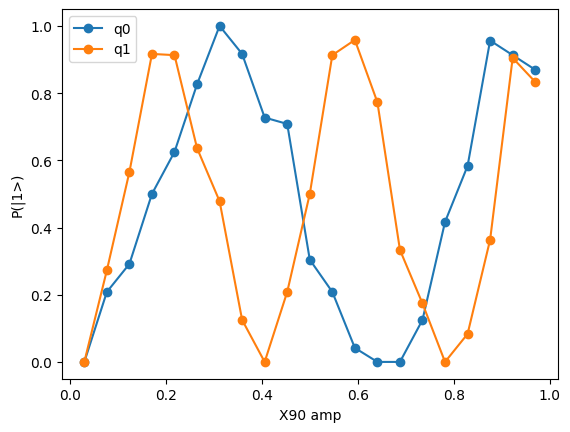

Amplitude [0, 1] X90 n_gates=4: ok=True  [96s]  proposal={'qubit/0/x90/amp': 0.1670898914171011, 'qubit/1/x90/amp': 0.09918894186568152}
q0: X90 amp -> 0.16709  (true ~0.16167)
q1: X90 amp -> 0.09919  (true ~0.09700)


In [11]:
mark('S3 amplitude + phase')
cfg = cfg1q()
ac = step(Amplitude(cfg, QUBITS, gate='X90', n_gates=1, amp_span=(0.03, 0.97), points=21, shots=24))

for q in QUBITS:
    plt.plot(ac.data[q]['x'] / units.AMP_SCALE, ac.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('X90 amp'); plt.ylabel('P(|1>)'); plt.legend(); plt.show()

cfg = cfg1q()
af = step(Amplitude(cfg, QUBITS, gate='X90', n_gates=4, amp_span=(0.7, 1.3), relative_amp=True,
                    points=9, shots=24))
for q in QUBITS:
    print(f"q{q}: X90 amp -> {cfg[f'qubit/{q}/x90/amp']:.5f}  (true ~{TRUE_AMP[q]:.5f})")

In [12]:
cfg = cfg1q()
ph = step(Phase(cfg, QUBITS, span=0.3, points=7, shots=16))

for q in QUBITS:
    vz = cfg[f'qubit/{q}/x90/vz']
    print(f'q{q}: X90 virtual-Z pair -> [{vz[0]:+.4f}, {vz[1]:+.4f}] rad  (planted 0)')

Phase [0, 1]: ok=False  [99s]  proposal={}
  fit failed — config left unchanged (fail-loud, spec 13 §2)
q0: X90 virtual-Z pair -> [+0.0000, +0.0000] rad  (planted 0)
q1: X90 virtual-Z pair -> [+0.0000, +0.0000] rad  (planted 0)


### The X180 — the other pulse, and its own axis

The reference calibrates the π everywhere it calibrates the π/2, so this notebook does too.
`Amplitude(gate='X')` is the same Rabi cosine against the config's own `x` pulse, targeting a full
π (the repetition guard becomes n % 2 rather than n % 4). On X6Y3 the X is the X90 at **double
length**, so the same amplitude is already a π — which is what the fit should land on.

`Phase(gate='X')` is *not* the X90 measurement re-pointed (spec 14 §3.3). It is one circuit,
`X90 · X · X90` — a 2π rotation that only returns to |0⟩ when the X sits on the X90s' axis — swept
over the X's own **axis** phase (`qubit/{q}/x/phase`, the pulse's `phase` kwarg), not a virtual-Z
pair. The fringe runs at 2φ, so the recovered axis is defined mod π: both solutions are the same
gate.

[ 2012.1s] S3 X180 amplitude + axis


Amplitude [0, 1] X n_gates=1: ok=True  [207s]  proposal={'qubit/0/x/amp': 0.1599667500681339, 'qubit/0/rabi': 7.493590431142418e-05, 'qubit/1/x/amp': 0.096800999312215, 'qubit/1/rabi': 0.00012382525062372152}


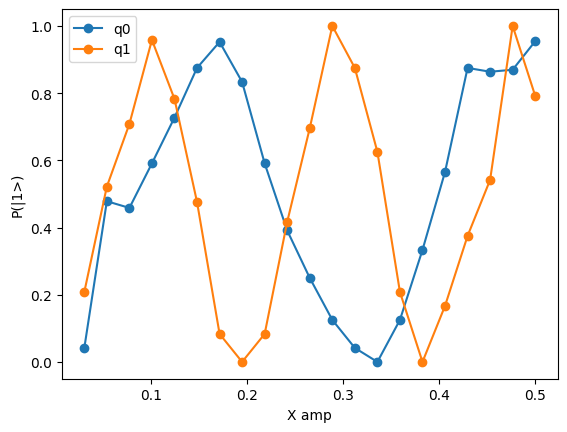

Phase [0, 1] X: ok=True  [172s]  proposal={'qubit/0/x/phase': 0.05596479602507401, 'qubit/1/x/phase': 0.022064554984562505}
q0: X amp -> 0.15997  (the X90's own 0.16167 IS a π at double length)   axis -> +0.0560 rad, +0.0560 mod π (planted 0)
q1: X amp -> 0.09680  (the X90's own 0.09700 IS a π at double length)   axis -> +0.0221 rad, +0.0221 mod π (planted 0)


In [13]:
mark('S3 X180 amplitude + axis')
cfg = cfg1q()
# HALF the X90's amp span covers the same rotation: the X is twice as long, so σ per code doubles
xa = step(Amplitude(cfg, QUBITS, gate='X', n_gates=1, amp_span=(0.03, 0.5), points=21, shots=24))

for q in QUBITS:
    plt.plot(xa.data[q]['x'] / units.AMP_SCALE, xa.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('X amp'); plt.ylabel('P(|1>)'); plt.legend(); plt.show()

cfg = cfg1q()
xp = step(Phase(cfg, QUBITS, gate='X', points=13, shots=32))
for q in QUBITS:
    axis = float(cfg.get(f'qubit/{q}/x/phase', 0.0))
    print(f"q{q}: X amp -> {cfg[f'qubit/{q}/x/amp']:.5f}  (the X90's own {TRUE_AMP[q]:.5f} IS a π "
          f"at double length)   axis -> {axis:+.4f} rad, {math.remainder(axis, math.pi):+.4f} mod π "
          f"(planted 0)")

## The RPE polish on the gate

The same amplification argument as stage 2, applied to the gate itself: repeating the X90 `d` times
multiplies its rotation error `d`-fold. `RPEAmplitude` recovers the per-gate rotation angle and
corrects the amplitude by the ratio `(π/2)/Θ`.

Each rung reads four trains — `d`, `d+1`, `d+2`, `d+3`. Two X90s make a π rotation, so the `d+2`
train returns the exact opposite outcome to the `d` train: that pairing is what keeps a readout
fringe not centred on ½ (T1 decay before the latch) from leaking into the angle.

[ 2391.2s] S3 RPE amplitude


RPEAmplitude [0, 1]: ok=True  [306s]  proposal={'qubit/0/x90/amp': 0.15816919736630913, 'qubit/1/x90/amp': 0.09854893521234397}
q0: rotation angle 1.7590 rad (target 1.5708)  amp 0.17712 -> 0.15817  (true ~0.16167)
q1: rotation angle 1.4861 rad (target 1.5708)  amp 0.09324 -> 0.09855  (true ~0.09700)


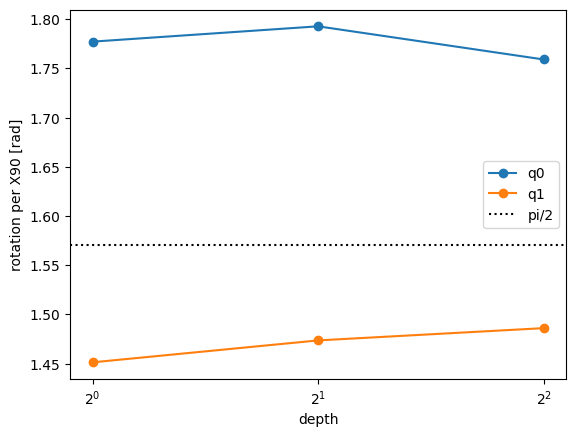

In [14]:
mark('S3 RPE amplitude')
cfg = cfg1q()
for q in QUBITS:                                  # hand the polish step a known 6% error
    cfg[f'qubit/{q}/x90/amp'] = float(cfg[f'qubit/{q}/x90/amp']) * (1.06 if q == 0 else 0.94)
before = {q: float(cfg[f'qubit/{q}/x90/amp']) for q in QUBITS}

cal = RPEAmplitude(cfg, QUBITS, depths=(1, 2, 4), shots=96)
ra = step(cal)

for q in QUBITS:
    a = cal.angles[q]
    plt.plot(a.depths, a.estimates['X'], 'o-', label=f'q{q}')
    print(f"q{q}: rotation angle {cal.recovered_angle[q]:.4f} rad (target {np.pi / 2:.4f})  "
          f"amp {before[q]:.5f} -> {cfg[f'qubit/{q}/x90/amp']:.5f}  (true ~{TRUE_AMP[q]:.5f})")
plt.axhline(np.pi / 2, color='k', ls=':', label='pi/2')
plt.xscale('log', base=2); plt.xlabel('depth'); plt.ylabel('rotation per X90 [rad]')
plt.legend(); plt.show()

## The RPE polish on the gate's axis

`Phase` fixes the axis by a line crossing; RPE amplifies the same error. The **interleaved** echo
`Z90·X90·X90·Z90·Z90·X90·X90·Z90` repeated `d` times cancels the rotation *angle* and amplifies the
tilt of the rotation axis out of the drive plane, so pairing it with the direct train recovers both
the rotation (`X`) and the tilt (`Z`) at once — qcal's linearized estimator.

What it can see is worth stating precisely: a uniform pulse `phase` applied to every X90 alike
conjugates the whole sequence by an Rz, which a z-in/z-out experiment is blind to by construction —
that is a frame convention, not an error. What the echo measures is the frame advance *between*
gates being wrong for the phase the pulse leaves behind, i.e. an ac-Stark shift or a mis-set
virtual-Z pair. So the cell plants a wrong pair and asks RPE to undo it.

[ 2697.1s] S3 RPE phase


RPEPhase [0, 1]: ok=True  [886s]  proposal={'qubit/0/x90/vz': [0.0017325289269166377, 0.0017325289269166377], 'qubit/1/x90/vz': [-0.04145118696234795, -0.04145118696234795]}
q0: planted vz +0.200  correction -0.1983 (want -0.200)  -> vz +0.0017   last good depth=4  contrast=[0.82, 0.59, 0.52]
q1: planted vz -0.200  correction +0.1585 (want +0.200)  -> vz -0.0415   last good depth=4  contrast=[0.85, 0.65, 0.52]


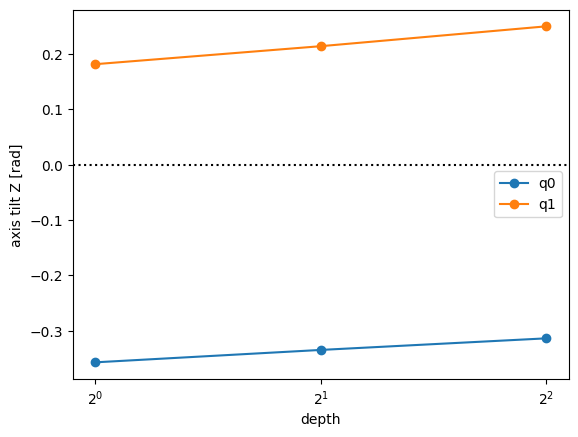

In [15]:
mark('S3 RPE phase')
drv.sim.set_model({'kind': 'multi', 'models': [
    dict(kind='twolevel', core=q, rabi_rad_per_amp=RABI[q], readout_code=RO_CODE[q],
         readout_amp=10000.0, readout_phase=0.0, f_ge=F_GE[q], t1=1000, t2=3000,
         noise_scale=200.0, noise_seed=53 + q, collapse=True) for q in ALL]})

PLANT_VZ = {0: +0.20, 1: -0.20}                    # a wrong virtual-Z pair, one sign each
cfg = Config.from_qcal(WORK)
cfg['reset/relax'] = 2.5e-05                       # depth 4 is 19 X90s on the paced train grid
for q in QUBITS:
    cfg[f'qubit/{q}/x90/vz'] = [PLANT_VZ[q], PLANT_VZ[q]]

cal = RPEPhase(cfg, QUBITS, depths=(1, 2, 4), shots=64)
rph = step(cal)

for q in QUBITS:
    a = cal.angles[q]
    plt.plot(a.depths, a.estimates['Z'], 'o-', label=f'q{q}')
    print(f"q{q}: planted vz {PLANT_VZ[q]:+.3f}  correction {cal.recovered_tilt[q]:+.4f} "
          f"(want {-PLANT_VZ[q]:+.3f})  -> vz {cfg[f'qubit/{q}/x90/vz'][0]:+.4f}   "
          f"last good depth={a.last_good_depth}  contrast={np.round(a.contrast, 2).tolist()}")
plt.axhline(0.0, color='k', ls=':')
plt.xscale('log', base=2); plt.xlabel('depth'); plt.ylabel('axis tilt Z [rad]')
plt.legend(); plt.show()

## Coherence — T1 and T2*

Now that the X90 works, the two decay constants can be measured: `T1` preps |1⟩ and sweeps the
delay before the readout; `T2` is a Ramsey at a deliberate detuning whose fringe envelope decays at
T2*. Together they bound every depth used later — an RPE ladder or a gate train run past them
measures noise, which is exactly the failure the RPE contrast floor guards against.

The model plants T1 = 600 batches (6 µs, matching the tree) and a **shorter** T2* = 800 batches
(8 µs), which is what the cals have to find — the tree's stored T2* of 30 µs is deliberately wrong.

[ 3583.4s] S3 coherence


T1 [0, 1]: ok=True  [162s]  proposal={'qubit/0/T1': np.float64(1.1453498587181148e-05), 'qubit/1/T1': np.float64(4.436392001462469e-06)}


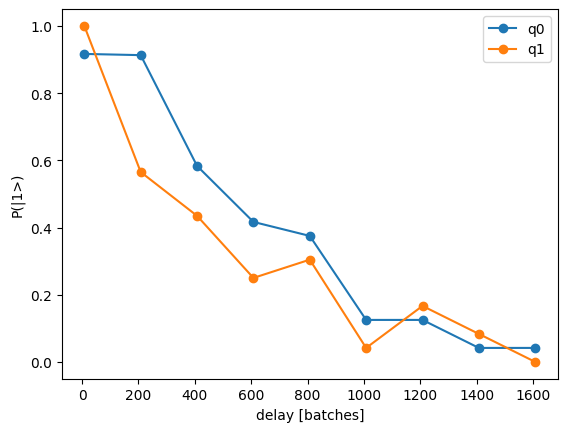

q0: T1 -> 11.45 us   (planted 600 batches = 6.00 us)
q1: T1 -> 4.44 us   (planted 600 batches = 6.00 us)


In [16]:
mark('S3 coherence')
drv.sim.set_model({'kind': 'multi', 'models': [
    dict(kind='twolevel', core=q, rabi_rad_per_amp=RABI[q], readout_code=RO_CODE[q],
         readout_amp=10000.0, readout_phase=0.0, f_ge=F_GE[q], t1=600, t2=800,
         noise_scale=200.0, noise_seed=51 + q, collapse=True) for q in ALL]})

cfg = cfg1q()
t1 = step(T1(cfg, QUBITS, points=9, t0=8e-8, dt=2e-6, shots=24))
for q in QUBITS:
    plt.plot(t1.data[q]['x'], t1.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('delay [batches]'); plt.ylabel('P(|1>)'); plt.legend(); plt.show()
for q in QUBITS:
    print(f"q{q}: T1 -> {cfg[f'qubit/{q}/T1'] * 1e6:.2f} us   (planted 600 batches = 6.00 us)")

T2 [0, 1]: ok=True  [216s]  proposal={'qubit/0/T2': np.float64(4.95544945039562e-06), 'qubit/1/T2': np.float64(5.368620858433393e-06)}


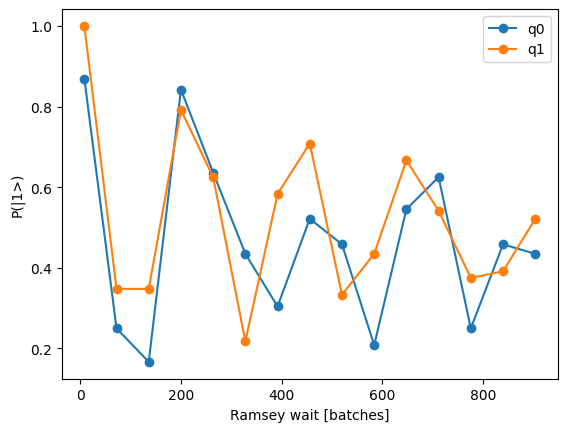

q0: T2* -> 4.96 us   (planted 800 batches = 8.00 us)
q1: T2* -> 5.37 us   (planted 800 batches = 8.00 us)


In [17]:
cfg = cfg1q()
t2 = step(T2(cfg, QUBITS, detune=442e3, points=15, t0=8e-8, dt=6.4e-7, shots=24))

for q in QUBITS:
    plt.plot(t2.data[q]['x'], t2.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('Ramsey wait [batches]'); plt.ylabel('P(|1>)'); plt.legend(); plt.show()
for q in QUBITS:
    print(f"q{q}: T2* -> {cfg[f'qubit/{q}/T2'] * 1e6:.2f} us   (planted 800 batches = 8.00 us)")

## The EF subspace

The |1⟩→|2⟩ manifold above the computational one — needed because leakage into |2⟩ is what DRAG
suppresses, and because X6Y3's sandwich CZ pairs shelve through it. The hardware `res` bit is
2-level, so P(|2⟩) is read host-side through a 3-level `ClassifierN` trained from per-level RAW
clouds (planted here with `init_level`; the hardware twin preps |2⟩ with a GE π then the stored
EF X).

[ 3961.3s] S3 EF — 3-level classifier


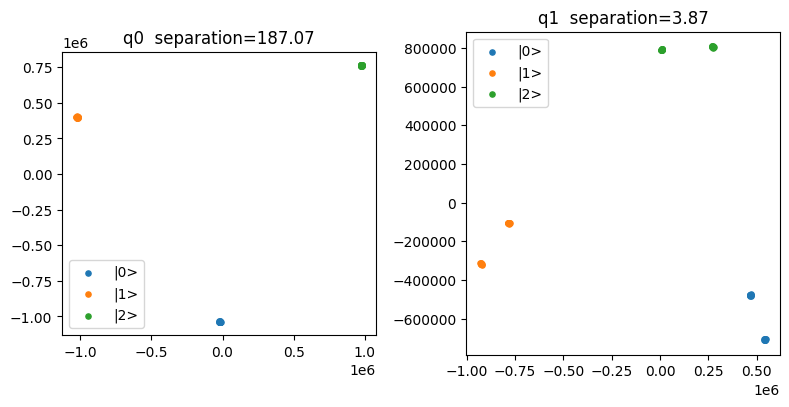

In [18]:
mark('S3 EF — 3-level classifier')
cfg = Config.from_qcal(WORK)

def train_classifiers(shots=24):
    clouds = {q: [] for q in QUBITS}
    for level in range(3):                     # plant each level on BOTH models, capture RAW clouds
        drv.sim.set_model({'kind': 'multi', 'models': [
            dict(kind='threelevel', core=q, readout_code=RO_CODE[q], readout_amp=15000.0,
                 init_level=level, collapse=True, noise_scale=200.0, noise_seed=7 + 3 * q + level)
            for q in QUBITS]})
        series = Experiment(cfg, QUBITS, {q: [] for q in QUBITS}, {q: () for q in QUBITS}, (),
                            Measure.raw(), shots, label='clouds').run(drv)
        for q in QUBITS:
            clouds[q].append(series[q].y)
    return {q: ClassifierN(clouds[q]) for q in QUBITS}

CLF = train_classifiers()
fig, axes = plt.subplots(1, len(QUBITS), figsize=(8, 4))
for q, ax in zip(QUBITS, axes):
    for lvl, c in enumerate(CLF[q].clusters):
        ax.scatter(c[:, 0], c[:, 1], s=14, label=f'|{lvl}>')
    ax.set_title(f'q{q}  separation={CLF[q].separation:.2f}')
    ax.set_aspect('equal'); ax.legend()
plt.tight_layout(); plt.show()
assert all(CLF[q].separation > 1.0 for q in QUBITS), '3-level clusters must separate'

In [19]:
def rabi_ge_pi(q):
    '''The GE Rabi rate that makes the CALIBRATED X90.X90 prep a full pi (reads the working tree).'''
    a = float(cfg[f'qubit/{q}/x90/amp'])
    gp = gate_pulse(cfg, q, m)
    return (math.pi / 2) / gate_sigma(m, gp, float(cfg[f'qubit/{q}/freq']), units._amp_code(a))

RABI_EF = {}                                   # ONE EF Rabi period over the amp sweep
for q in QUBITS:
    RABI_EF[q] = 2 * math.pi / gate_sigma(m, resolve(cfg, q, 'EF/x90', m).pulse, F_EF[q], units._amp_code(0.97))

def ef_models(seed):
    return [dict(kind='threelevel', core=q, f_ge=F_GE[q], f_ef=F_EF[q],
                 rabi_ge_rad_per_amp=rabi_ge_pi(q), rabi_ef_rad_per_amp=RABI_EF[q],
                 readout_code=RO_CODE[q], readout_amp=15000.0, init_level=0, collapse=True,
                 t1=600, noise_scale=200.0, noise_seed=seed + q) for q in QUBITS]

D_EF = {0: +60, 1: -60}                        # the planted EF carrier errors (both signs)
cfg = Config.from_qcal(WORK)
for q in QUBITS:
    off = units._freq_code(F_EF[q], m.params) + D_EF[q]
    cfg[f'qubit/{q}/EF/freq'] = float(units.code_to_freq(off, m.params))
cfg.save_qcal(WORK)
print('EF carriers mis-set by', D_EF, 'codes; planted EF Rabi rates:', RABI_EF)

EF carriers mis-set by {0: 60, 1: -60} codes; planted EF Rabi rates: {0: 4.943390667568951e-05, 1: 4.943390667568951e-05}


In [20]:
mark('S3 EF frequency')
cfg = Config.from_qcal(WORK)
drv.sim.set_model({'kind': 'multi', 'models': ef_models(seed=23)})
# ladder +-100/+-200 codes on the committed EF test's 40 ns wait grid
efr = step(EFFrequency(cfg, QUBITS, CLF, detune=units.code_to_freq(100, m.params), n_detune=4,
                       t0=8e-08, dt=4e-08, points=9, shots=24))

for q in QUBITS:
    d0 = abs(units.code_to_freq(units._freq_code(F_EF[q], m.params) + D_EF[q], m.params) - F_EF[q])
    print(f"q{q}: EF freq err {d0:.4g} -> {abs(cfg[f'qubit/{q}/EF/freq'] - F_EF[q]):.4g} Hz")

[ 4005.8s] S3 EF frequency


Frequency [0, 1]: ok=False  [481s]  proposal={'qubit/0/EF/freq': 450226538.5327416}
  fit failed — config left unchanged (fail-loud, spec 13 §2)
q0: EF freq err 1.465e+06 -> 1.465e+06 Hz
q1: EF freq err 1.465e+06 -> 1.465e+06 Hz


/config/build/agentic-rv-dev/software/riscq/cal/fits.py:67: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model, x, y, p0=list(p0), maxfev=20000)
/config/build/agentic-rv-dev/software/riscq/cal/fits.py:187: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model, x, y, p0=[a0 or sgn, b0, c0], maxfev=20000)


In [21]:
mark('S3 EF amplitude + phase')
cfg = Config.from_qcal(WORK)
drv.sim.set_model({'kind': 'multi', 'models': ef_models(seed=27)})
efa = step(EFAmplitude(cfg, QUBITS, CLF, gate='X90', n_gates=1, points=15, shots=24))

cfg = Config.from_qcal(WORK)
drv.sim.set_model({'kind': 'multi', 'models': ef_models(seed=29)})
efx = step(EFAmplitude(cfg, QUBITS, CLF, gate='X', n_gates=1, points=15, shots=24))
for q in QUBITS:
    print(f"q{q}: EF x90 amp -> {cfg[f'qubit/{q}/EF/x90/amp']:.5f}   "
          f"EF x amp -> {cfg[f'qubit/{q}/EF/x/amp']:.5f}")

[ 4487.0s] S3 EF amplitude + phase


Amplitude [0, 1] EF/X90 n_gates=1: ok=True  [200s]  proposal={'qubit/0/EF/x90/amp': 0.24271618494029254, 'qubit/0/EF/rabi': 4.941421388561345e-05, 'qubit/1/EF/x90/amp': 0.2781551879645484, 'qubit/1/EF/rabi': 4.291621391282163e-05}


Amplitude [0, 1] EF/X n_gates=1: ok=True  [199s]  proposal={'qubit/0/EF/x/amp': 0.24735681265733941, 'qubit/0/EF/rabi': 4.8438085761355855e-05, 'qubit/1/EF/x/amp': 0.24809169909829817, 'qubit/1/EF/rabi': 4.809940698906525e-05}
q0: EF x90 amp -> 0.24272   EF x amp -> 0.24736
q1: EF x90 amp -> 0.27816   EF x amp -> 0.24809


In [22]:
cfg = Config.from_qcal(WORK)
drv.sim.set_model({'kind': 'multi', 'models': ef_models(seed=31)})
efp = step(EFPhase(cfg, QUBITS, CLF, points=9, span=0.25, shots=24, relative_phase=True))

for q in QUBITS:
    vz = cfg[f'qubit/{q}/EF/x90/vz']
    print(f'q{q}: EF X90 virtual-Z pair -> [{vz[0]:+.4f}, {vz[1]:+.4f}] rad')

Phase [0, 1]: ok=False  [244s]  proposal={'qubit/1/EF/x90/vz': [0.1576821692772537, 0.1576821692772537]}
  fit failed — config left unchanged (fail-loud, spec 13 §2)
q0: EF X90 virtual-Z pair -> [+0.0000, +0.0000] rad
q1: EF X90 virtual-Z pair -> [+0.0000, +0.0000] rad


### The 3-level confusion matrix and `rcorr`

`ReadoutFidelity(n_levels=3)` measures the full 3×3 matrix over RAW shots at the |0⟩/|1⟩/|2⟩ preps,
and `rcorr(P, cmat)` inverts it: a population read through an imperfect discriminator becomes the
population the qubit actually had, which is what makes a leakage number honest (spec 14 F2).

It sits **after** the EF cals rather than next to the classifier, because its |2⟩ row is a real
prep — a GE π followed by the config's EF X (`_ef_prep_prog`) — not a planted level. Measuring it
before `EFAmplitude(gate='X')` has calibrated that pulse gives a |2⟩ row that is not |2⟩; on this
co-sim it is worse than that, since the classifier-training cell above leaves the model *planted*
at level 2, so every prep reads |2⟩ and the matrix comes out singular — the notebook's own reason
for the ordering.

In [23]:
mark('S3 3-level confusion')
drv.sim.set_model({'kind': 'multi', 'models': ef_models(seed=33)})   # a live model, init_level=0
cfg = Config.from_qcal(WORK)
rof3 = ReadoutFidelity(cfg, QUBITS, shots=24, gate='X90', n_levels=3, classifier=CLF).run(drv)
rof3.apply()                       # the matrix lands at readout/{q}/cmat, for rcorr to consume
rof3.cfg.save_qcal(WORK)

for q in QUBITS:
    cmat = rof3.data[q]['confusion']
    print(f'q{q} 3-level confusion (row = prepared, col = classified):')
    print(np.round(cmat, 3))
    if abs(np.linalg.det(cmat)) < 1e-6:
        print('   singular — the three preps did not separate, so rcorr has nothing to invert')
        continue
    measured = np.array([0.0, 0.9, 0.1]) @ cmat          # a true 90/10 |1>/|2> mix, as it READS
    print(f'   a true [0, 0.9, 0.1] reads as {np.round(measured, 3)} '
          f'-> rcorr gives {np.round(rcorr(measured, cmat), 3)}')

[ 5129.7s] S3 3-level confusion


q0 3-level confusion (row = prepared, col = classified):
[[1.    0.    0.   ]
 [0.208 0.792 0.   ]
 [0.167 0.25  0.583]]
   a true [0, 0.9, 0.1] reads as [0.204 0.738 0.058] -> rcorr gives [-0.   0.9  0.1]
q1 3-level confusion (row = prepared, col = classified):
[[1.    0.    0.   ]
 [0.    1.    0.   ]
 [0.083 0.125 0.792]]
   a true [0, 0.9, 0.1] reads as [0.008 0.912 0.079] -> rcorr gives [-0.   0.9  0.1]


## DRAG — shaping the pulse away from the EF transition

Leakage out of the computational subspace is driven by the pulse's own spectral content **at the
EF transition**. `optimize_fast_drag` is qcal's `optimize_FAST_DRAG`: a host-side coordinate
descent over the FAST_DRAG hyperparameters (`N`, `weights`) that minimises `|FFT(envelope)|` at
that frequency. The envelope and its transform are the entire measurement — **no hardware is
involved**, which is why this cell runs against the real X6Y3 tree and its own map rather than the
co-sim's square-envelope stand-in (spec 14 F3).

Its partner, `Leakage` (a 101×X90 train read for P(|2⟩) while one config value is swept), is *not*
run here: the co-sim's `ThreeLevelModel` rotates only the stronger of the two transitions, so a GE
drive never populates |2⟩ and there is no leakage to plant. It is exercised host-pure by
`tests/test_cal_drag.py` and belongs to the hardware twin.

In [24]:
mark('S3 DRAG (host-only)')
from riscq.cal.analysis.drag import ef_spectral_weight

HW_YAML = SW.parent / 'examples' / 'cal-config-x6y3.yaml'
m_hw = SocMap(SocParams.from_json((SW / 'configs' / 'x6y3.json').read_text()))
hw = Config.from_qcal(HW_YAML)

for q in (0, 6):
    # mis-set the envelope so the descent has something to find: the tree's own stored values are
    # already DRAG-calibrated, so recovering them IS the check.
    hw[f'qubit/{q}/x90/kwargs'] = {**dict(hw[f'qubit/{q}/x90/kwargs']),
                                   'N': 8, 'weights': [6.0, 6.0]}
    before = ef_spectral_weight(hw, q, m_hw)
    best = optimize_fast_drag(hw, q, m_hw)[f'qubit/{q}/x90/kwargs']
    after = ef_spectral_weight(hw, q, m_hw, 'x90', best)
    print(f"q{q}: |FFT| at f_EF  {before:.4g} -> {after:.4g}  ({before / after:.1f}x less leakage "
          f"drive)   N 8 -> {best['N']},  weights [6.0, 6.0] -> {best['weights']}")

[ 5175.0s] S3 DRAG (host-only)
q0: |FFT| at f_EF  0.02942 -> 0.002693  (10.9x less leakage drive)   N 8 -> 2,  weights [6.0, 6.0] -> [0.1, 0.1]
q6: |FFT| at f_EF  0.9886 -> 0.06468  (15.3x less leakage drive)   N 8 -> 2,  weights [6.0, 6.0] -> [0.1, 0.1]


# Stage 4 — the CZ

X6Y3 is fixed-frequency with no coupler, so the CZ is the **drive form**: both qubits' own drive
lines play a tone at a shared frequency near the |11⟩↔|02⟩ resonance, and the conditional phase
comes from the avoided crossing there. The chain seeds that frequency from the 1Q spectrum, maps
the landscape around it, then refines each knob in turn.

In [25]:
mark('S4 two-qubit')
RELAX_2Q = 8e-06                     # 800 batches — the JAZZ/CZ co-sim gates' grid

def cfg2q():
    c = Config.from_qcal(WORK)
    c['reset/relax'] = RELAX_2Q      # in-memory only: reset is not a calibrated artefact
    return c

cfg = cfg2q()
CZ_AMP = 0.35
F_CZ_TRUE = (F_GE[0] + 2 * F_GE[1] + F_EF[1]) / 4          # the model's own resonance (code 10240)
czd = _cz_dur_batches(cfg, PAIR, m)
SIG_CZ = gate_sigma(m, _cz_pulse(cfg, PAIR, m, czd, 0), F_CZ_TRUE, units._amp_code(CZ_AMP))
RABI_CZ = math.pi / SIG_CZ           # two aligned lines: |E| = 2A -> a 2pi round trip over czd
ZZ_TRUE = 2 * math.pi * 0.4e6 / m.params.dsp_freq_hz       # +400 kHz always-on ZZ

def twoqubit_model(seed):
    return dict(kind='twoqubit', control=0, target=1,      # NO 'coupler' key = the drive form
                f_ge=[F_GE[0], F_GE[1]], f_ef=[F_EF[0], F_EF[1]],
                rabi_ge=[rabi_ge_pi(0), rabi_ge_pi(1)], rabi_ef=[0.0, 0.0],
                rabi_cz_rad_per_amp=RABI_CZ, zz_rad_per_batch=ZZ_TRUE,
                readout_code=[RO_CODE[0], RO_CODE[1]], readout_amp=[10000.0, 10000.0],
                level_phases=[0.0, math.pi, math.pi / 2],  # 2-level pair readout; |2> reads as noise
                collapse=True, t1=250, noise_scale=250.0, noise_seed=seed)

drv.sim.set_model(twoqubit_model(seed=33))
print(f'czd={czd} batches  f_cz_true={F_CZ_TRUE / MHz:.1f} MHz  zz={ZZ_TRUE:.4f} rad/batch')

[ 5175.0s] S4 two-qubit
czd=30 batches  f_cz_true=250.0 MHz  zz=0.0251 rad/batch


## The seed, and the always-on ZZ

`calc_cz_frequency(form='drive')` puts the tone at `(f₁₁ + f₀₂)/4` straight from the 1Q spectrum
this notebook just calibrated — the starting point before any two-qubit measurement. Here the
notebook **takes** that seed: the tree's stored `CZ/freq` is deliberately 8 MHz off the planted
resonance, and every cal below scores by the conditionality R, which is flat that far out — a
chain started from the stale value never sees a conditional response and every step fails
fail-loud. (The hardware twin does the opposite and only *compares*: on a real already-calibrated
tree the stored value beats a seed recomputed from freshly-fitted 1Q numbers.)

`JAZZ` then measures the **always-on** ZZ the pair carries even with no gate playing: on a
fixed-frequency chip there is no knob to null it, so JAZZ characterises rather than calibrates.

In [26]:
cfg = Config.from_qcal(WORK)
before = float(cfg[f'two_qubit/{pair_key(PAIR)}/CZ/freq'])
calc_cz_frequency(cfg, [PAIR], state='02', form='drive')     # ... and TAKE it: see above
cfg.save_qcal(WORK)
print(f"CZ/freq: {before / MHz:.3f} -> {cfg[f'two_qubit/{pair_key(PAIR)}/CZ/freq'] / MHz:.3f} MHz "
      f"seeded   (model resonance {F_CZ_TRUE / MHz:.3f})")

cfg = cfg2q()
jz = step(JAZZ(cfg, PAIR, detune=2 * MHz, points=15, shots=24))
print(f"ZZ11 -> {jz.proposal.get(f'two_qubit/{pair_key(PAIR)}/ZZ11', float('nan')) / 1e3:+.1f} kHz "
      f"(planted +400.0; JAZZ reports the magnitude of the always-on shift)")

CZ/freq: 242.000 -> 249.646 MHz seeded   (model resonance 250.000)


JAZZ (0, 1): ok=True  [311s]  proposal={'two_qubit/(0, 1)/ZZ11': -419673.15632221405}
ZZ11 -> -419.7 kHz (planted +400.0; JAZZ reports the magnitude of the always-on shift)


## The 2D landscape — amplitude × frequency

Before walking the 1D chain, `CZAmpFreqSweep` maps the whole neighbourhood: the drive amplitude
(lockstep on both lines) against the drive frequency, scoring each point by the same
conditionality R the 1D cals use. The argmax is the seed the chain starts from, and the shape of
the ridge is what tells you whether the 1D cuts below are being taken through a real optimum
(spec 14 F4).

[ 5485.7s] S4 CZ 2D landscape


CZAmpFreqSweep (0, 1): ok=True  [639s]  proposal={'two_qubit/(0, 1)/CZ/freq': 251635742.1875, 'two_qubit/(0, 1)/CZ/pulse': [{'channel': 'Q0.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.45, 'phase': 0.0}}, {'channel': 'Q1.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.45, 'phase': 2.0}}, {'channel': 'Q0.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/0/GE/freq', 'kwargs': {'phase': 0.0}}, {'channel': 'Q1.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/1/GE/freq', 'kwargs': {'phase': 0.0}}, {'channel': 'Q2.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/2/GE/freq', 'kwargs': {'phase': 0.0}}]}


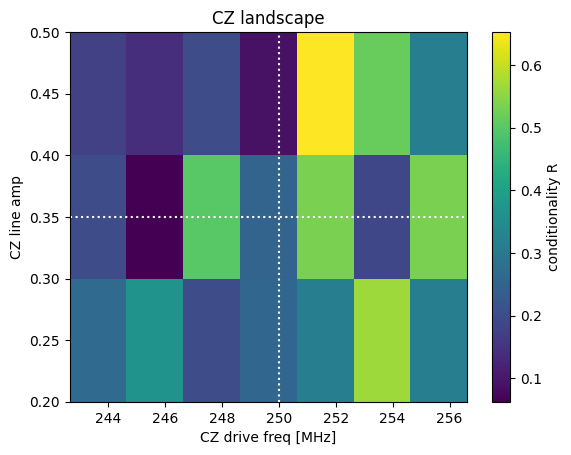

argmax -> amp 0.4500, freq 251.636 MHz, R 0.653 (planted 0.35, 250.0)


In [27]:
mark('S4 CZ 2D landscape')
drv.sim.set_model(twoqubit_model(seed=34))
cfg = cfg2q()
afs = step(CZAmpFreqSweep(cfg, PAIR, amps=(0.25, 0.35, 0.45), span=6 * MHz, points=7,
                          ngates=1, shots=16))

d = afs.data[PAIR]
plt.pcolormesh(d['freqs'] / MHz, d['amps'], d['R'], shading='nearest')
plt.colorbar(label='conditionality R')
plt.axvline(F_CZ_TRUE / MHz, color='w', ls=':'); plt.axhline(CZ_AMP, color='w', ls=':')
plt.xlabel('CZ drive freq [MHz]'); plt.ylabel('CZ line amp'); plt.title('CZ landscape')
plt.show()
best = afs.fit[PAIR]
print(f"argmax -> amp {best['amp']:.4f}, freq {best['freq'] / MHz:.3f} MHz, R {best['R']:.3f} "
      f"(planted {CZ_AMP}, {F_CZ_TRUE / MHz:.1f})")

## The 1D chain

In the spec-04 order, each step refining one knob at the previous step's optimum:
`CZSweep('freq')` (the |11⟩-population dip re-pins the resonance) → `CZFrequency`
(conditionality-R argmax) → `RelativePhase` (the target line's tone phase — the two lines sum
coherently, so R peaks where the round trip closes) → `CZAmplitude` (the R error-amplification
ladder) → `LocalPhases` (the single-qubit Z each CZ leaves behind).

`RelativePhase` runs **twice**: R vs phase is a cosine, so a full turn can only be argmax'd (the
parabola fit fails and the class falls back to the sweep grid), while a narrow window fits the
vertex — but a narrow window only helps once it brackets the optimum. The tree here starts 2 rad
out, so the coarse turn finds the neighbourhood and the narrow pass refines it. On an
already-calibrated tree the reference runs the narrow pass alone (spec 14 §2), which is what the
hardware twin does.

In [28]:
drv.sim.set_model(twoqubit_model(seed=35))
cfg = cfg2q()
czs = step(CZSweep(cfg, PAIR, 'freq', span=6 * MHz, points=11, shots=24))

drv.sim.set_model(twoqubit_model(seed=37))
cfg = cfg2q()
czf = step(CZFrequency(cfg, PAIR, span=4 * MHz, points=9, ngates=1, shots=24))
print(f"CZ/freq -> {cfg[f'two_qubit/{pair_key(PAIR)}/CZ/freq'] / MHz:.3f} MHz "
      f"(truth {F_CZ_TRUE / MHz:.1f})")

CZSweep (0, 1): ok=True  [60s]  proposal={'two_qubit/(0, 1)/CZ/freq': 249703508.23521158}


CZFrequency (0, 1): ok=False  [405s]  proposal={}
  fit failed — config left unchanged (fail-loud, spec 13 §2)
CZ/freq -> 249.704 MHz (truth 250.0)


RelativePhase (0, 1): ok=True  [313s]  proposal={'two_qubit/(0, 1)/CZ/pulse': [{'channel': 'Q0.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.45, 'phase': 0.0}}, {'channel': 'Q1.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.45, 'phase': 2.0}}, {'channel': 'Q0.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/0/GE/freq', 'kwargs': {'phase': 0.0}}, {'channel': 'Q1.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/1/GE/freq', 'kwargs': {'phase': 0.0}}, {'channel': 'Q2.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/2/GE/freq', 'kwargs': {'phase': 0.0}}]}


RelativePhase (0, 1): ok=False  [313s]  proposal={}
  fit failed — config left unchanged (fail-loud, spec 13 §2)


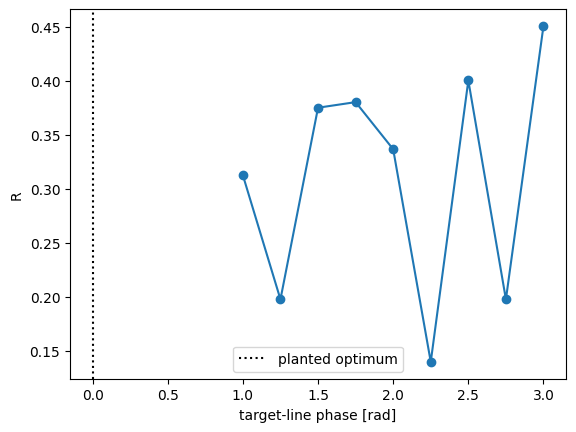

In [29]:
drv.sim.set_model(twoqubit_model(seed=39))
cfg = cfg2q()
rp = step(RelativePhase(cfg, PAIR, points=9, shots=16))            # coarse: a full turn, argmax

drv.sim.set_model(twoqubit_model(seed=40))
cfg = cfg2q()
rp = step(RelativePhase(cfg, PAIR, span=2.0, points=9, shots=16))  # refine: narrow, parabola vertex

d = rp.data[PAIR]
plt.plot(d['x'], d['R'], 'o-'); plt.axvline(0.0, color='k', ls=':', label='planted optimum')
plt.xlabel('target-line phase [rad]'); plt.ylabel('R'); plt.legend(); plt.show()

CZAmplitude (0, 1): ok=True  [350s]  proposal={'two_qubit/(0, 1)/CZ/pulse': [{'channel': 'Q0.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.5416911871223349, 'phase': 0.0}}, {'channel': 'Q1.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.5416911871223349, 'phase': 2.0}}, {'channel': 'Q0.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/0/GE/freq', 'kwargs': {'phase': 0.0}}, {'channel': 'Q1.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/1/GE/freq', 'kwargs': {'phase': 0.0}}, {'channel': 'Q2.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/2/GE/freq', 'kwargs': {'phase': 0.0}}]}


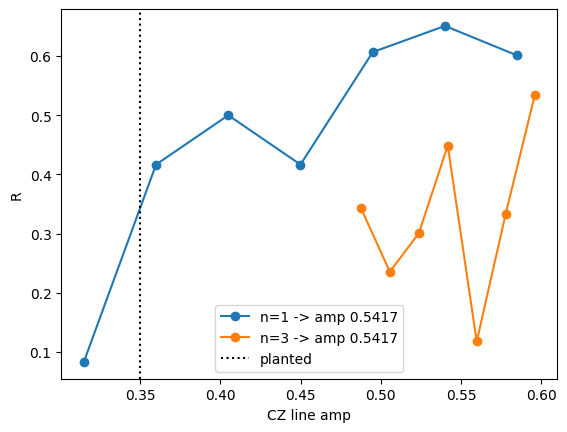

In [30]:
drv.sim.set_model(twoqubit_model(seed=41))
cfg = cfg2q()
cza = step(CZAmplitude(cfg, PAIR, n_gates=(1, 3), window=0.3, points=7, shots=12))

for p in cza.data[PAIR]['passes']:
    plt.plot(p['x'], p['R'], 'o-', label=f"n={p['n']} -> amp {p['amp']:.4f}")
plt.axvline(CZ_AMP, color='k', ls=':', label='planted')
plt.xlabel('CZ line amp'); plt.ylabel('R'); plt.legend(); plt.show()

LocalPhases (0, 1): ok=True  [109s]  proposal={'two_qubit/(0, 1)/CZ/pulse': [{'channel': 'Q0.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.5416911871223349, 'phase': 0.0}}, {'channel': 'Q1.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.5416911871223349, 'phase': 2.0}}, {'channel': 'Q0.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/0/GE/freq', 'kwargs': {'phase': 1.4140051512379568}}, {'channel': 'Q1.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/1/GE/freq', 'kwargs': {'phase': 0.5076515872657419}}, {'channel': 'Q2.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/2/GE/freq', 'kwargs': {'phase': 0.0}}]}


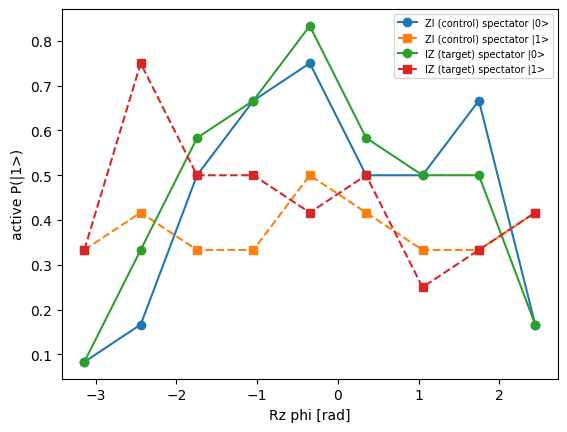

In [31]:
drv.sim.set_model(twoqubit_model(seed=43))
cfg = cfg2q()
lp = step(LocalPhases(cfg, PAIR, points=9, shots=12))

d = lp.data[PAIR]
for role, dd in (('ZI (control)', d['ZI']), ('IZ (target)', d['IZ'])):
    for sp in (0, 1):
        plt.plot(d['phi'], dd[sp]['P'], 'o-' if sp == 0 else 's--',
                 label=f'{role} spectator |{sp}>')
plt.xlabel('Rz phi [rad]'); plt.ylabel('active P(|1>)'); plt.legend(fontsize=7); plt.show()

## The RPE polish on the CZ

The same amplification argument once more, now on the two-qubit gate. `CZRPE` runs three
conditional-Ramsey ladders — the target's fringe with the control held |0⟩ and |1⟩, and (with the
roles swapped) the control's fringe with the target held |1⟩ — and inverts the three accumulated
angles into the CZ's **generator** angles `ZZ`, `IZ`, `ZI`, of which the ideal gate
`diag(1, 1, 1, −1)` has `(−π/2, +π/2, +π/2)`.

Each rung is read at **both close signs** in both quadratures (`quad` 0..3 = ±Y90/±X90). That is
what makes the Ramsey qubit's own marginal enough: the ratio the angle comes from is
`(2a·cos)/(2c)`, so a fringe not centred on ½ — T1 decay before the latch — divides out exactly, and
no joint two-qubit post-selection is needed (spec 14 F5 finding 5).

Two things this run shows, and one it does not:

- **`ZZ` lands on the ideal −π/2**, which is the conditional phase the whole chain above was
  calibrating. That is the number to read.
- **contrast is the ladder's own alarm.** The CZ rungs are long (a depth-2 rung is two 300 ns CZs
  plus three X90s), so this cell plants a longer-T1 model than the chain used: with the pair's T1
  at the chain's 250 batches the depth-2 rung decoheres and the ladder is cut back to depth 1.
- **`IZ`/`ZI` are reported, not written here.** Their *sum* — the frame-independent part — matches
  the ideal π, but the split between the two qubits differs from the frame `LocalPhases` just
  wrote, so applying the residual on this planted model would re-split a gate that is already
  calibrated. The class's write-back (a damped `+=` on the pair's virtual-Z entries) is pinned by
  the committed F5 gates, which plant a config-vz error and invert it exactly.

`ZZ`'s own residual is reported and never written by the class either: its knobs (`CZ/freq`, the
amps, the relative phase) need a measured slope — qcal's `LinearResponse`/optimizer stack, out of
scope by spec 14 §4. The remedy for a large one is a re-run of `CZFrequency`/`CZAmplitude`.

RPE polishes a working CZ; it cannot find one. Hence its place at the end of the chain.

[ 7674.0s] S4 CZ RPE


CZRPE (0, 1): ok=True
ZZ: -1.7045 rad   (ideal -1.5708, residual -0.1337)
IZ: +1.0689 rad   (ideal +1.5708, residual -0.5019)
ZI: +0.7117 rad   (ideal +1.5708, residual -0.8591)
IZ + ZI = +1.7806 rad (ideal +3.1416) — the frame-INDEPENDENT part, the one this model reproduces
contrast [0.37, 0.3]   last good depth=2


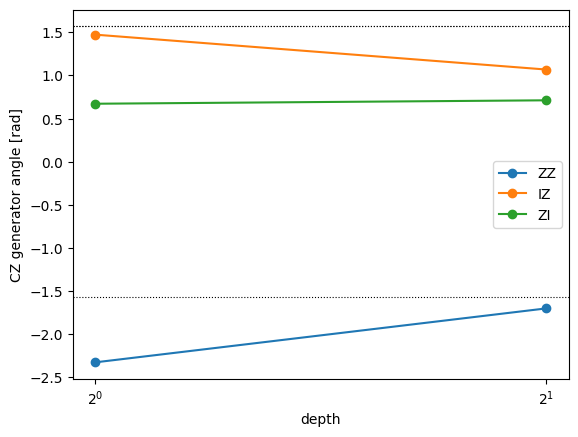

In [32]:
mark('S4 CZ RPE')
# the ladder has to outlive two CZs + three X90s, so plant the chain's model with a longer T1
drv.sim.set_model(dict(twoqubit_model(seed=44), t1=600))
cfg = cfg2q()
cal = CZRPE(cfg, PAIR, depths=(1, 2), shots=64)
czr = cal.run(drv)                      # REPORTED, not applied — see above
print(f'{czr.label}: ok={czr.ok}')

a = cal.angles.get(PAIR)
if a is not None:
    for name in ('ZZ', 'IZ', 'ZI'):
        plt.plot(a.depths, a.estimates[name], 'o-', label=name)
        plt.axhline(CZ_TARGETS[name], color='k', ls=':', lw=0.8)
        print(f'{name}: {a.trusted[name]:+.4f} rad   (ideal {CZ_TARGETS[name]:+.4f}, '
              f'residual {a.trusted_error[name]:+.4f})')
    print(f'IZ + ZI = {a.trusted["IZ"] + a.trusted["ZI"]:+.4f} rad (ideal {np.pi:+.4f}) — the '
          f'frame-INDEPENDENT part, the one this model reproduces')
    print(f'contrast {np.round(a.contrast, 2).tolist()}   last good depth={a.last_good_depth}')
    plt.xscale('log', base=2); plt.xlabel('depth'); plt.ylabel('CZ generator angle [rad]')
    plt.legend(); plt.show()

## The spectator phase

A pair's CZ also kicks the frame of ring neighbours that sit in its pulse list as extra virtual-Z
entries. `SpectatorPhase` runs the bystander's Ramsey on the third core around one CZ fire and
writes the spectator's channel-matched entry — the wrap-aware plain mean, with no conditional-π
removal, because the spectator is outside the gate.

In [33]:
mark('S4 spectator')
spect_rabi = (math.pi / 2) / x90_sigma(2, 0.5)             # its X90 (amp 0.5) = pi/2
drv.sim.set_model({'kind': 'multi', 'models': [
    twoqubit_model(seed=45),
    dict(kind='twolevel', core=SPECT, rabi_rad_per_amp=spect_rabi, readout_code=RO_CODE[SPECT],
         readout_amp=10000.0, readout_phase=0.0, f_ge=F_GE[SPECT], t1=600, t2=3000,
         noise_scale=250.0, noise_seed=47, collapse=True)]})
cfg = cfg2q()
sp = step(SpectatorPhase(cfg, PAIR, spectator=SPECT, points=9, shots=12))

[ 8188.4s] S4 spectator


SpectatorPhase (0, 1) Q2: ok=True  [63s]  proposal={'two_qubit/(0, 1)/CZ/pulse': [{'channel': 'Q0.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.5416911871223349, 'phase': 0.0}}, {'channel': 'Q1.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.5416911871223349, 'phase': 2.0}}, {'channel': 'Q0.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/0/GE/freq', 'kwargs': {'phase': 1.4140051512379568}}, {'channel': 'Q1.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/1/GE/freq', 'kwargs': {'phase': 0.5076515872657419}}, {'channel': 'Q2.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/2/GE/freq', 'kwargs': {'phase': 0.13747152928233541}}]}


# Stage 5 — validation

The walkthrough validates with randomised benchmarking; that needs a licensed dependency the
project does not carry (spec 14 §4), so the check here is **error amplification**, which resolves
the same coherent errors: the conditionality R at n = 1 must survive n = 3 CZs, because three
gates compound any residual frequency, amplitude or phase error into a visible drop.

In [34]:
mark('S5 validation')
drv.sim.set_model(twoqubit_model(seed=49))
cfg = cfg2q()
for n in (1, 3):
    R = CZFrequency(cfg, PAIR, span=0.0, points=1, ngates=n, shots=24).run(drv).data[PAIR]['R']
    print(f'R at n={n} CZs: {float(R[0]):.3f}')

[ 8251.7s] S5 validation


R at n=1 CZs: 0.292


R at n=3 CZs: 0.224


## What the process wrote

The calibrated working tree against the pristine config of record — every path the process moved,
through the full `from_qcal`/`save_qcal` round trip.

In [35]:
def flat(c, prefix='', out=None):
    out = {} if out is None else out
    for k, v in (c if isinstance(c, dict) else c.to_dict()).items():
        p = f'{prefix}/{k}' if prefix else str(k)
        if isinstance(v, dict):
            flat(v, p, out)
        else:
            out[p] = v
    return out

before, after = flat(Config.from_qcal(SRC)), flat(Config.from_qcal(WORK))
changed = [p for p in sorted(after) if after[p] != before.get(p)]
print(f'{len(changed)} paths changed:')
for p in changed:
    b, a = before.get(p), after[p]
    if isinstance(a, float) and isinstance(b, float):
        print(f'  {p}: {b:.6g} -> {a:.6g}')
    else:
        print(f'  {p}: {b} -> {a}')
mark('done')

34 paths changed:
  qubit/0/EF/freq: 4.5e+08 -> 4.51465e+08
  qubit/0/EF/x/amp: 0.4 -> 0.247357
  qubit/0/EF/x90/amp: 0.4 -> 0.242716
  qubit/0/T1: 6e-06 -> 1.14535e-05
  qubit/0/T2: 3e-05 -> 4.95545e-06
  qubit/0/freq: 5e+07 -> 5.00058e+07
  qubit/0/x/amp: 0.495 -> 0.159967
  qubit/0/x/phase: 0 -> 0.0559648
  qubit/0/x90/amp: 0.5 -> 0.158169
  qubit/0/x90/vz: [0.0, 0.0] -> [0.0017325289269166377, 0.0017325289269166377]
  qubit/1/EF/freq: 6.5e+08 -> 6.48535e+08
  qubit/1/EF/x/amp: 0.4 -> 0.248092
  qubit/1/EF/x90/amp: 0.4 -> 0.278155
  qubit/1/T1: 6e-06 -> 4.43639e-06
  qubit/1/T2: 3e-05 -> 5.36862e-06
  qubit/1/freq: 1.5e+08 -> 1.50022e+08
  qubit/1/x/amp: 0.495 -> 0.096801
  qubit/1/x/phase: 0 -> 0.0220646
  qubit/1/x90/amp: 0.5 -> 0.0985489
  qubit/1/x90/vz: [0.0, 0.0] -> [-0.04145118696234795, -0.04145118696234795]
  readout/0/demod/delay: 0 -> 8e-08
  readout/0/demod/dur: 4e-07 -> 4e-07
  readout/0/demod/phase: 0 -> 1.57719
  readout/0/dur: 5.6e-07 -> 4e-07
  readout/1/amp: 0.5 ->

## Tear down the co-sim

In [36]:
drv.sim.set_model({'kind': 'zero'})
server.stop(drv)
print('cosim stopped')

cosim stopped
